## **Key EDA Questions:**
- Which states provide data consistently?
- What cleaning is needed for null values like 9999?
- How can we best operationalize (measure) recidivism by counting repeating ID records?
- Based on all of the above, what should be our choices of treatment and control states?

In [1]:
import warnings

# warnings.filterwarnings('ignore')

import pandas as pd

pd.set_option("mode.copy_on_write", True)

## 1. Load Data
Use `gdown` to access data from Google Drive and read the csv file using pandas.

In [2]:
import os
import gdown

# import pandas as pd

file_id = "1jkBkjOsdr-0hhUgj3p2J7pk1Welkk7A1"

# check if a csv was already created earlier and download only if it wasn't
if not os.path.exists("dataset.csv"):
    gdown.download(id=file_id, output="dataset.csv", quiet=False)

df = pd.read_csv("dataset.csv", sep="\t")
df.head()

,ABT_INMATE_ID,SEX,ADMTYPE,OFFGENERAL,EDUCATION,ADMITYR,RELEASEYR,MAND_PRISREL_YEAR,PROJ_PRISREL_YEAR,PARELIG_YEAR,SENTLGTH,OFFDETAIL,RACE,AGEADMIT,AGERELEASE,TIMESRVD,RELTYPE,STATE
0,A012021000000090128,1,1,2,9,2013,2013,9999,9999,9999,4,8,1,5,5,0,3,1
1,A012021000000110168,1,1,1,9,2004,9999,9999,9999,9999,4,3,1,5,9,9,9,1
2,A012021000000090187,1,1,2,9,2009,2009,9999,9999,9999,0,11,9,1,1,0,1,1
3,A012021000000010425,1,3,3,9,2016,2016,9999,9999,9999,2,12,9,3,3,0,3,1
4,A012021000000090117,1,1,1,9,2009,2017,9999,9999,9999,4,4,9,1,2,3,1,1


## 2. Explore Data
Issues flagged in Tea's analysis earlier:
- prisoner IDs repeat as many as 46 times, which is illogical
- The value 9999 appears to represent cases where release has not yet occurred or is not recorded.

Summary from earlier:
- **Observations:** 13,897,856
- **Unique inmates:** 7,316,619
- **Repeat inmate records:** 6,581,237
- **States covered:** 44
- **Missing values:** none

**Admission years:** start at 1950  
**Release years:** start at 1971

**Variables:**

- **ABT_INMATE_ID** – Unique identifier for each inmate
- **SEX** – Sex of the inmate
- **ADMTYPE** – Admission type to prison
- **OFFGENERAL** – General category of offense
- **OFFDETAIL** – Detailed offense category
- **EDUCATION** – Education level of the inmate
- **ADMITYR** – Year the inmate was admitted to prison
- **RELEASEYR** – Year the inmate was released from prison
- **MAND_PRISREL_YEAR** – Mandatory prison release year
- **PROJ_PRISREL_YEAR** – Projected prison release year
- **PARELIG_YEAR** – Year the inmate becomes eligible for parole
- **SENTLGTH** – Length of the sentence
- **RACE** – Race of the inmate
- **AGEADMIT** – Age at admission
- **AGERELEASE** – Age at release
- **TIMESRVD** – Time served in prison
- **RELTYPE** – Type of release from prison
- **STATE** – State where the incarceration occurred

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13897856 entries, 0 to 13897855
Data columns (total 18 columns):
 #   Column             Dtype 
---  ------             ----- 
 0   ABT_INMATE_ID      object
 1   SEX                int64 
 2   ADMTYPE            int64 
 3   OFFGENERAL         int64 
 4   EDUCATION          int64 
 5   ADMITYR            int64 
 6   RELEASEYR          int64 
 7   MAND_PRISREL_YEAR  int64 
 8   PROJ_PRISREL_YEAR  int64 
 9   PARELIG_YEAR       int64 
 10  SENTLGTH           int64 
 11  OFFDETAIL          int64 
 12  RACE               int64 
 13  AGEADMIT           int64 
 14  AGERELEASE         int64 
 15  TIMESRVD           int64 
 16  RELTYPE            int64 
 17  STATE              int64 
dtypes: int64(17), object(1)
memory usage: 1.9+ GB


In [4]:
# sense check for my sanity
for col in df.columns:
    print(f"\n{df[col].value_counts()}")


ABT_INMATE_ID
A062021000000022552    46
A362021000000005215    46
A062021000000058980    40
A062021000000077121    39
A062021000000041577    39
                       ..
A292021000000115195     1
A292021000000421432     1
A292021000000208103     1
A292021000000333227     1
A012021000000090128     1
Name: count, Length: 7316619, dtype: int64

SEX
1    12385438
2     1512418
Name: count, dtype: int64

ADMTYPE
1    9234199
2    4191968
9     315602
3     156087
Name: count, dtype: int64

OFFGENERAL
2    3981188
1    3887684
3    3802927
4    2071566
5      84957
9      69534
Name: count, dtype: int64

EDUCATION
9    13897856
Name: count, dtype: int64

ADMITYR
2008    650530
2009    647680
2007    632919
2010    625681
2006    617798
         ...  
1952        29
1953        21
1951        21
1955        20
1950        16
Name: count, Length: 72, dtype: int64

RELEASEYR
9999    996467
2009    641718
2010    623037
2008    611278
2011    605536
2007    596154
2006    568435
2012    542220


In [5]:
# many records' admit year is unknown
df[df["ADMITYR"] == 9999]  # .count()

,ABT_INMATE_ID,SEX,ADMTYPE,OFFGENERAL,EDUCATION,ADMITYR,RELEASEYR,MAND_PRISREL_YEAR,PROJ_PRISREL_YEAR,PARELIG_YEAR,SENTLGTH,OFFDETAIL,RACE,AGEADMIT,AGERELEASE,TIMESRVD,RELTYPE,STATE
1271,A012021000000062444,1,2,3,9,9999,2017,9999,9999,9999,4,12,1,1,3,4,1,1
138969,A012021000000042290,2,1,3,9,9999,2020,9999,9999,9999,2,12,1,1,3,4,9,1
1015368,A062021000000830057,1,1,2,9,9999,1993,9999,9999,9999,3,7,1,1,5,4,3,6
1793083,A062021000001043824,1,1,2,9,9999,1993,9999,9999,9999,0,7,1,2,5,4,3,6
2053682,A062021000001272319,1,1,1,9,9999,1999,9999,9999,9999,6,5,1,2,5,4,9,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10882461,A422021000000195821,1,1,1,9,9999,1998,9999,9999,9999,9,1,1,1,5,4,3,42
11278558,A442021000000004484,1,1,1,9,9999,2006,2014,2009,1998,4,1,1,1,3,4,1,44
11283579,A442021000000012150,1,1,1,9,9999,9999,9999,9999,9999,6,1,2,1,9,9,9,44
13591428,A542021000000017248,1,1,2,9,9999,2006,9999,9999,9999,4,10,1,1,3,4,1,54


In [6]:
# of these, around half don't have release year either
df[(df["ADMITYR"] == 9999) & (df["RELEASEYR"] == 9999)]  # .count()

,ABT_INMATE_ID,SEX,ADMTYPE,OFFGENERAL,EDUCATION,ADMITYR,RELEASEYR,MAND_PRISREL_YEAR,PROJ_PRISREL_YEAR,PARELIG_YEAR,SENTLGTH,OFFDETAIL,RACE,AGEADMIT,AGERELEASE,TIMESRVD,RELTYPE,STATE
4560176,A132021000000236468,1,1,1,9,9999,9999,9999,9999,9999,6,1,2,2,9,9,9,13
4560769,A132021000000699003,1,1,2,9,9999,9999,1944,9999,9999,0,8,2,1,9,9,9,13
4572342,A132021000000860633,1,1,1,9,9999,9999,1973,9999,9999,4,3,2,1,9,9,9,13
4573759,A132021000000158807,1,1,9,9,9999,9999,9999,9999,9999,0,99,2,1,9,9,9,13
4574888,A132021000000317452,1,1,5,9,9999,9999,1940,9999,9999,0,14,2,1,9,9,9,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5222162,A132021000000036750,1,1,2,9,9999,9999,1946,9999,9999,1,8,2,2,9,9,9,13
5225048,A132021000000444288,1,1,2,9,9999,9999,1963,9999,9999,4,7,2,1,9,9,9,13
5225426,A132021000000285558,1,1,5,9,9999,9999,1941,9999,9999,0,14,2,1,9,9,9,13
5226151,A132021000000156347,1,1,2,9,9999,9999,1944,9999,9999,2,7,1,1,9,9,9,13


In [7]:
# many missing in release year
df[df["RELEASEYR"] == 9999]  # .count()

,ABT_INMATE_ID,SEX,ADMTYPE,OFFGENERAL,EDUCATION,ADMITYR,RELEASEYR,MAND_PRISREL_YEAR,PROJ_PRISREL_YEAR,PARELIG_YEAR,SENTLGTH,OFFDETAIL,RACE,AGEADMIT,AGERELEASE,TIMESRVD,RELTYPE,STATE
1,A012021000000110168,1,1,1,9,2004,9999,9999,9999,9999,4,3,1,5,9,9,9,1
10,A012021000000012020,1,1,1,9,2009,9999,9999,9999,9999,4,6,1,2,9,9,9,1
25,A012021000000090252,2,1,1,9,2020,9999,9999,9999,9999,0,6,9,2,9,9,9,1
35,A012021000000166845,1,1,1,9,2007,9999,9999,9999,9999,6,4,9,3,9,9,9,1
52,A012021000000090355,1,1,1,9,1998,9999,9999,9999,9999,4,4,9,1,9,9,9,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13897804,A112020000001769573,1,1,3,9,2003,9999,2004,2008,9999,1,12,2,9,9,9,9,11
13897828,A112020000001770847,2,1,1,9,2019,9999,2019,9999,9999,0,5,2,9,9,9,9,11
13897834,A112020000001771060,1,1,1,9,2013,9999,2044,2040,9999,5,1,2,9,9,9,9,11
13897840,A112020000001771189,1,1,1,9,2019,9999,2020,2020,9999,1,5,2,9,9,9,9,11


In [8]:
# check: if release year 9999 basically just means NOT released yet, the prisoner ID should NOT be repeated. If it's repeated, that means at least n-1 of that ID's release years are genuinely MISSING, and not just because the person is still in prison.

df[df["RELEASEYR"] == 9999]["ABT_INMATE_ID"].nunique()

996467

In [9]:
# # parole eligibility year vs release year correlation prompted this
# # exclude 9999 first
# df_eda = df[~(df == 9999).any(axis=1)]
# df_eda.drop(df["ABT_INMATE_ID"], axis=1)

# # correlation matrix
# print(df_eda.corr())
# print(df_eda.shape)  # make sure some rows actually got excluded lol

In [ ]:
df["OFFGENERAL"].value_counts()

OFFGENERAL
2    3981188
1    3887684
3    3802927
4    2071566
5      84957
9      69534
Name: count, dtype: int64

**Things to note:**

Coded variables based on codebook:
- SEX: 1=Male, 2=Female (check # of missing values?)

- SENTLGTH: bins for year ranges, 0=less than a year, 6=life sentence or death sentence, 9=missing (108968 are missing)

- OFFDETAIL: Offense category, 14=other, 99=missing (69534 missing records) -- might be correlated with other vars

- OFFGENERAL: Offense category, 69534 missing

- RACE: 1318720 missing, but we won't be looking at this anyway

- AGEADMIT: 5 categories, 9 for missing (51784 missing records)

- AGERELEASE: 5 categories, 9 for missing (1043993 missing records)

- TIMESERVED: 5 categories, 9 for missing (996467 missing records)

- RELTYPE: 3 categories, 9 for missing (1646999 missing records)

Others:
- EDUCATION: This has ONLY missing values, just 9s for undocumented educ level. So it's basically unsusable

- ADMITYR: 658 missing, out of which 312 don't have Release Year either, so depending on how we operationalize recidivism, these might become unusable records

- RELEASEYR: 996,467 missing and all of these have unique inmate IDs, so safe to assume that these are all people that are still in prison. After operationalising recidivism, we must check that none of these IDs appear in the IDs we get for recided inmates

- MAND_PRISREL_YEAR: This has weird values in the 3000s or 5000s because this is the legal mandatory release year, when the inmate would have served their full sentence and must be released regardless of a voluntary legal decision to release them. This is a legal theoretical value, so we can disregard this as a dimension. In fact, adding this might throw a regression model off course.

- PROJ_PRISREL_YEAR: Same logic as MAND_, just disregards "good conduct time". So we probably should ignore this one as well

- PARELIG_YEAR: Year of parole eligibility, depends largely on the type of crime.

- STATE

### 2.1. Check States
According to the codebook, each code has been saved as a numerical code (sad). Replacing with strings might be easier for us to deal with. From Tea's analysis we know that there are 44 unique states.

In [10]:
state_map = {
    1: "Alabama",
    2: "Alaska",
    4: "Arizona",
    5: "Arkansas",
    6: "California",
    8: "Colorado",
    9: "Connecticut",
    10: "Delaware",
    11: "District of Columbia",
    12: "Florida",
    13: "Georgia",
    15: "Hawaii",
    16: "Idaho",
    17: "Illinois",
    18: "Indiana",
    19: "Iowa",
    20: "Kansas",
    21: "Kentucky",
    22: "Louisiana",
    23: "Maine",
    24: "Maryland",
    25: "Massachusetts",
    26: "Michigan",
    27: "Minnesota",
    28: "Mississippi",
    29: "Missouri",
    30: "Montana",
    31: "Nebraska",
    32: "Nevada",
    33: "New Hampshire",
    34: "New Jersey",
    35: "New Mexico",
    36: "New York",
    37: "North Carolina",
    38: "North Dakota",
    39: "Ohio",
    40: "Oklahoma",
    41: "Oregon",
    42: "Pennsylvania",
    44: "Rhode Island",
    45: "South Carolina",
    46: "South Dakota",
    47: "Tennessee",
    48: "Texas",
    49: "Utah",
    50: "Vermont",
    51: "Virginia",
    53: "Washington",
    54: "West Virginia",
    55: "Wisconsin",
}

df["STATE_NAME"] = df["STATE"].map(state_map)

# Verify
print(df["STATE_NAME"].unique())

['Alabama' 'Arizona' 'California' 'Colorado' 'Delaware' 'Florida'
 'Georgia' 'Illinois' 'Indiana' 'Iowa' 'Kansas' 'Kentucky' 'Louisiana'
 'Maine' 'Maryland' 'Massachusetts' 'Michigan' 'Minnesota' 'Mississippi'
 'Missouri' 'Montana' 'Nebraska' 'Nevada' 'New Hampshire' 'New Jersey'
 'New Mexico' 'New York' 'North Carolina' 'North Dakota' 'Ohio' 'Oklahoma'
 'Oregon' 'Pennsylvania' 'Rhode Island' 'South Carolina' 'South Dakota'
 'Tennessee' 'Texas' 'Utah' 'Washington' 'West Virginia' 'Wisconsin' nan
 'District of Columbia']


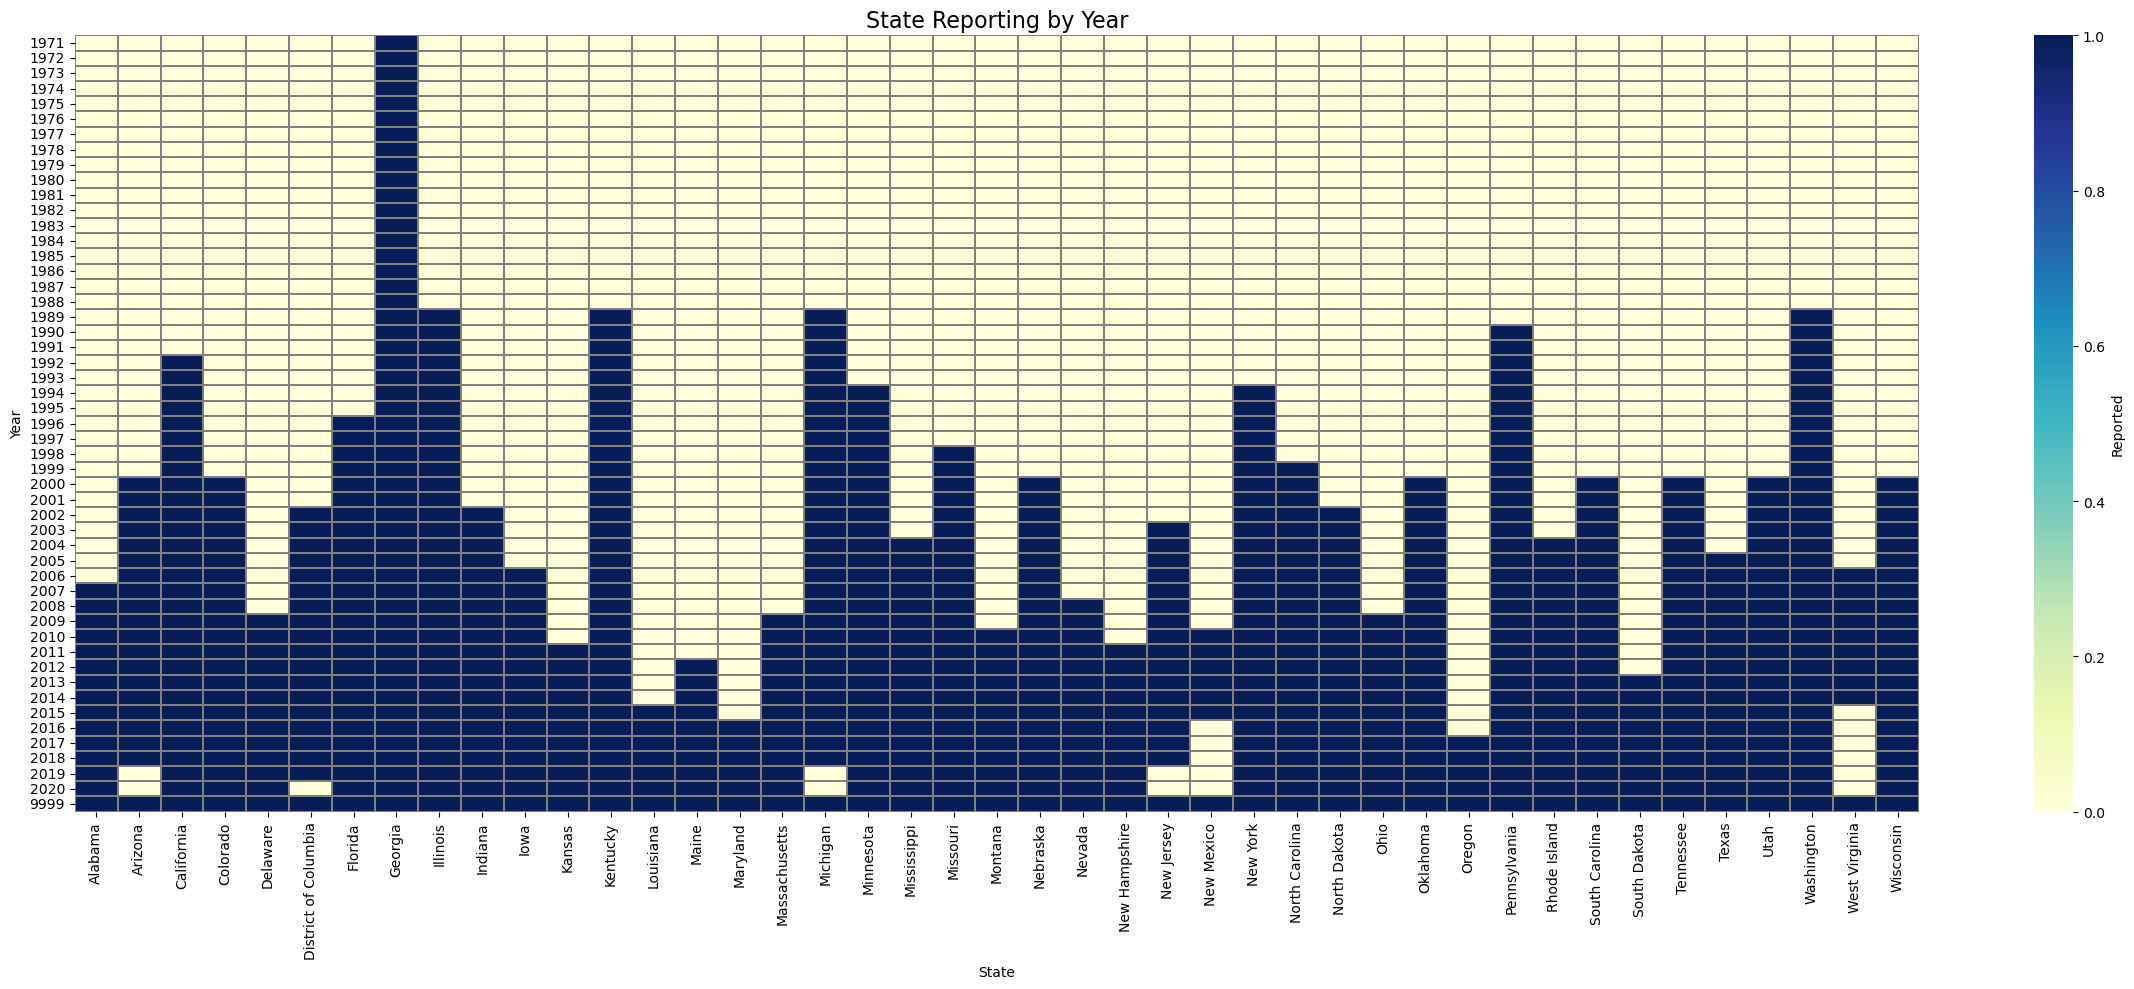

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create presence matrix
presence = (
    df.groupby(["RELEASEYR", "STATE_NAME"]).size().unstack(fill_value=0).clip(upper=1)
)

# Plot
plt.figure(figsize=(24, 10))
sns.heatmap(
    presence,
    cmap="YlGnBu",
    linewidths=0.3,
    linecolor="gray",
    cbar_kws={"label": "Reported"},
)
plt.title("State Reporting by Year", fontsize=16)
plt.xlabel("State")
plt.ylabel("Year")
plt.tight_layout()
plt.show()

NOTE: how can we detect if each state reports with 100% fidelity? Based on the codebook, we assume it's 100%.

## 3. Operationalize Recidivism
Count recurrences for each inmate ID. First, we need to check my some IDs repeat up to 46 times.

- Should the starting point of calculating this depend on the year our chosen treatment starts? Under consideration. Temporary measure would start at year 0.

In [12]:
df["ABT_INMATE_ID"].value_counts().index[0]

'A062021000000022552'

In [13]:
first_46_id_rows = df[df["ABT_INMATE_ID"] == "A062021000000022552"]
first_46_id_rows

,ABT_INMATE_ID,SEX,ADMTYPE,OFFGENERAL,EDUCATION,ADMITYR,RELEASEYR,MAND_PRISREL_YEAR,PROJ_PRISREL_YEAR,PARELIG_YEAR,SENTLGTH,OFFDETAIL,RACE,AGEADMIT,AGERELEASE,TIMESRVD,RELTYPE,STATE,STATE_NAME
577985,A062021000000022552,1,2,2,9,2011,2011,9999,9999,9999,1,8,3,3,3,0,1,6,California
579255,A062021000000022552,1,2,2,9,2008,2008,9999,9999,9999,1,9,3,3,3,0,1,6,California
616059,A062021000000022552,1,2,2,9,2010,2010,9999,9999,9999,1,8,3,3,3,0,1,6,California
743335,A062021000000022552,1,2,2,9,1996,1997,9999,9999,9999,1,7,9,2,2,0,1,6,California
746071,A062021000000022552,1,2,2,9,2004,2004,9999,9999,9999,1,7,3,2,2,0,1,6,California
748789,A062021000000022552,1,2,2,9,2011,2011,9999,9999,9999,1,8,3,3,3,0,1,6,California
748793,A062021000000022552,1,2,2,9,2009,2009,9999,2009,9999,1,8,3,3,3,0,1,6,California
748795,A062021000000022552,1,2,2,9,2006,2006,9999,2007,9999,1,9,3,3,3,0,1,6,California
748797,A062021000000022552,1,2,2,9,2003,2003,9999,2003,9999,1,7,3,2,2,0,1,6,California
748799,A062021000000022552,1,2,2,9,1999,1999,9999,9999,9999,1,11,9,2,2,0,9,6,California


In [14]:
first_46_id_rows.duplicated().sum()

np.int64(16)

In [15]:
df_drop_dupl = df.drop_duplicates()
print(df_drop_dupl.shape)
print(df.shape)
print(df.shape[0] - df_drop_dupl.shape[0])

(13768054, 19)
(13897856, 19)
129802


In [16]:
df_drop_dupl["ABT_INMATE_ID"].value_counts()  # .index[0]

ABT_INMATE_ID
A062021000000001692    32
A062021000000005541    32
A362021000000005215    31
A062021000000118873    30
A172021000000072078    30
                       ..
A292021000000354303     1
A292021000000577421     1
A292021000000114896     1
A292021000000335775     1
A012021000000090128     1
Name: count, Length: 7316619, dtype: int64

In [ ]:
df_drop_dupl["ABT_INMATE_ID"].value_counts().value_counts(normalize=True)

count
1     6.056634e-01
2     1.920142e-01
3     9.000551e-02
4     4.729275e-02
5     2.616318e-02
6     1.497153e-02
7     8.845616e-03
8     5.326641e-03
9     3.302208e-03
10    2.070218e-03
11    1.374815e-03
12    9.200971e-04
13    6.215986e-04
14    4.441942e-04
15    3.051956e-04
16    2.208670e-04
17    1.436456e-04
18    1.011396e-04
19    7.189113e-05
20    4.838300e-05
21    3.334874e-05
22    2.405483e-05
23    1.353084e-05
24    8.610534e-06
25    6.013707e-06
26    2.596828e-06
27    1.913452e-06
28    1.366752e-06
29    5.467006e-07
30    5.467006e-07
32    2.733503e-07
31    1.366752e-07
Name: proportion, dtype: float64

In [17]:
df_drop_dupl[df_drop_dupl["ABT_INMATE_ID"] == "A062021000000001692"]

,ABT_INMATE_ID,SEX,ADMTYPE,OFFGENERAL,EDUCATION,ADMITYR,RELEASEYR,MAND_PRISREL_YEAR,PROJ_PRISREL_YEAR,PARELIG_YEAR,SENTLGTH,OFFDETAIL,RACE,AGEADMIT,AGERELEASE,TIMESRVD,RELTYPE,STATE,STATE_NAME
595716,A062021000000001692,1,2,3,9,2010,2010,9999,2012,9999,2,12,2,4,4,0,1,6,California
621410,A062021000000001692,1,2,3,9,2002,2003,9999,2003,9999,2,12,2,3,3,0,1,6,California
758964,A062021000000001692,1,2,3,9,1996,1997,9999,9999,9999,2,12,2,2,2,0,1,6,California
769992,A062021000000001692,1,2,3,9,1992,1992,9999,9999,9999,2,12,2,2,2,0,1,6,California
772704,A062021000000001692,1,2,3,9,1995,1995,9999,9999,9999,2,12,2,2,2,0,1,6,California
772707,A062021000000001692,1,2,3,9,1990,1992,9999,9999,9999,2,12,2,2,2,1,1,6,California
778050,A062021000000001692,1,2,3,9,2013,2014,2015,2014,9999,2,12,2,4,4,0,1,6,California
785672,A062021000000001692,1,2,3,9,2005,2005,9999,9999,9999,2,12,2,3,3,0,1,6,California
785675,A062021000000001692,1,2,3,9,2000,2001,9999,9999,9999,2,12,2,3,3,0,1,6,California
808272,A062021000000001692,1,2,3,9,2006,2007,9999,9999,9999,2,12,2,3,3,0,1,6,California


In [ ]:
# recidivism count can be a new column storing the number of times each ID appears

**Policy research-driven questions**
1. ⁠Can you check to see if a certain individual is recorded with different scores of education IF they have multiple jailings?

2.⁠ ⁠⁠Could we, for any given year, understand the total population jailed versus total population - i know this will require the total population per state per year, but i do have this dataset from last year. I kinda want to create an idea of if this is a very crime prone state or not. 

3.⁠ ⁠⁠can you check to see how many individuals (as a percentage) have recorded incarcerations in different states (ie arrested in state A and then arrested in state B)

In [19]:
# Q1: answer is NO, insufficient data recorded
df["EDUCATION"].value_counts()

EDUCATION
9    13897856
Name: count, dtype: int64

In [20]:
# Q3
# Find prisoners that appear in more than one state
states_per_prisoner = df.groupby("ABT_INMATE_ID")["STATE_NAME"].nunique()
multi_state_prisoners = states_per_prisoner[states_per_prisoner > 1]

print(
    f"Number of prisoners with incarcerations in multiple states: {len(multi_state_prisoners)}"
)

Number of prisoners with incarcerations in multiple states: 0


- check in other datasets too for Q3

In [21]:
# Q2
stateyear_pop = pd.read_csv(
    "https://github.com/JoshData/historical-state-population-csv/raw/refs/heads/main/historical_state_population_by_year.csv",
    header=None,
    names=["STATE_ABBR", "YEAR", "POP"],
)
stateyear_pop

,STATE_ABBR,YEAR,POP
0,AK,1950,135000
1,AK,1951,158000
2,AK,1952,189000
3,AK,1953,205000
4,AK,1954,215000
...,...,...,...
6321,WY,2021,579662
6322,WY,2022,581742
6323,WY,2023,584666
6324,WY,2024,586722


In [22]:
statewise_criminals = df.groupby(["STATE_NAME", "ADMITYR"])["ABT_INMATE_ID"].count()
statewise_criminals

STATE_NAME  ADMITYR
Alabama     1952          1
            1958          1
            1962          1
            1965          1
            1968          1
                       ... 
Wisconsin   2016       9354
            2017       9292
            2018       9418
            2019       9229
            2020       5301
Name: ABT_INMATE_ID, Length: 2359, dtype: int64

In [23]:
# stateyear_pop['STATE_NAME'] =

state_abbrev_map = {
    "AL": "Alabama",
    "AK": "Alaska",
    "AZ": "Arizona",
    "AR": "Arkansas",
    "CA": "California",
    "CO": "Colorado",
    "CT": "Connecticut",
    "DE": "Delaware",
    "DC": "District of Columbia",
    "FL": "Florida",
    "GA": "Georgia",
    "HI": "Hawaii",
    "ID": "Idaho",
    "IL": "Illinois",
    "IN": "Indiana",
    "IA": "Iowa",
    "KS": "Kansas",
    "KY": "Kentucky",
    "LA": "Louisiana",
    "ME": "Maine",
    "MD": "Maryland",
    "MA": "Massachusetts",
    "MI": "Michigan",
    "MN": "Minnesota",
    "MS": "Mississippi",
    "MO": "Missouri",
    "MT": "Montana",
    "NE": "Nebraska",
    "NV": "Nevada",
    "NH": "New Hampshire",
    "NJ": "New Jersey",
    "NM": "New Mexico",
    "NY": "New York",
    "NC": "North Carolina",
    "ND": "North Dakota",
    "OH": "Ohio",
    "OK": "Oklahoma",
    "OR": "Oregon",
    "PA": "Pennsylvania",
    "RI": "Rhode Island",
    "SC": "South Carolina",
    "SD": "South Dakota",
    "TN": "Tennessee",
    "TX": "Texas",
    "UT": "Utah",
    "VT": "Vermont",
    "VA": "Virginia",
    "WA": "Washington",
    "WV": "West Virginia",
    "WI": "Wisconsin",
    "WY": "Wyoming",
}

# Apply to your new dataframe (replace 'STATE' with your column name)
stateyear_pop["STATE_NAME"] = stateyear_pop["STATE_ABBR"].map(state_abbrev_map)
stateyear_pop
# Verify
# print(stateyear_pop['STATE_NAME'].unique())

,STATE_ABBR,YEAR,POP,STATE_NAME
0,AK,1950,135000,Alaska
1,AK,1951,158000,Alaska
2,AK,1952,189000,Alaska
3,AK,1953,205000,Alaska
4,AK,1954,215000,Alaska
...,...,...,...,...
6321,WY,2021,579662,Wyoming
6322,WY,2022,581742,Wyoming
6323,WY,2023,584666,Wyoming
6324,WY,2024,586722,Wyoming


In [24]:
state_crime = statewise_criminals.to_frame(name="ABT_INMATE_ID").reset_index()

In [25]:
state_crime

,STATE_NAME,ADMITYR,ABT_INMATE_ID
0,Alabama,1952,1
1,Alabama,1958,1
2,Alabama,1962,1
3,Alabama,1965,1
4,Alabama,1968,1
...,...,...,...
2354,Wisconsin,2016,9354
2355,Wisconsin,2017,9292
2356,Wisconsin,2018,9418
2357,Wisconsin,2019,9229


In [26]:
merged_df = pd.merge(
    state_crime,
    stateyear_pop,
    left_on=["STATE_NAME", "ADMITYR"],
    right_on=["STATE_NAME", "YEAR"],
    how="left",
)
merged_df

,STATE_NAME,ADMITYR,ABT_INMATE_ID,STATE_ABBR,YEAR,POP
0,Alabama,1952,1,AL,1952.0,3068000.0
1,Alabama,1958,1,AL,1958.0,3163000.0
2,Alabama,1962,1,AL,1962.0,3323000.0
3,Alabama,1965,1,AL,1965.0,3443000.0
4,Alabama,1968,1,AL,1968.0,3446000.0
...,...,...,...,...,...,...
2354,Wisconsin,2016,9354,WI,2016.0,5775170.0
2355,Wisconsin,2017,9292,WI,2017.0,5793147.0
2356,Wisconsin,2018,9418,WI,2018.0,5809319.0
2357,Wisconsin,2019,9229,WI,2019.0,5824581.0
